In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

### Settings

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


### Load junction and intron cluster counts

In [4]:
# let's simulate using the mammary gland data
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4


In [5]:
# double check which cell types are present
cell_ids_conversion.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [6]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                    340
junction_id_index                                               8157
junc_count                                                       5.0
cluster_count                                                     10
clustminjunc                                                     5.0
juncratio                                                        0.5
cell_id              C20-B002309-3_57_F-1-1_Mammary_Gland_basal_cell
cell_type                                   Mammary_Gland_basal_cell
junction_id                                      7_80339350_80339550
Cluster                                                        52681
gene_id                                                       Unc45a
Name: 3438217, dtype: object
5.0
10


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [7]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

6594


In [8]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 6594/6594 [06:42<00:00, 16.40it/s]


6388
19164
   junction_id_index          junction_id  Cluster gene_id  \
0                 12  1_78692220_78694195      114   Acsl3   
1                 13  1_78694346_78696080      114   Acsl3   
2                 20  1_74236899_74246079      344   Arpc2   
3                 21  1_74246114_74248131      344   Arpc2   
4                 22  1_74255014_74255957      347   Arpc2   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [9]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                          171
junction_id_index                                                    10206
junc_count                                                            12.0
cluster_count                                                           24
clustminjunc                                                          12.0
juncratio                                                              0.5
cell_id                  B16-B002433-3_38_F-1-1_Mammary_Gland_stromal_cell
cell_type                                       Mammary_Gland_stromal_cell
junction_id                                           17_74492505_74493927
Cluster                                                             107613
gene_id_x                                                            Yipf4
gene_id_y                                                            Yipf4
new_junction_id_index                                                 4408
Name: 653671, dtype: obje

<Axes: xlabel='juncratio', ylabel='Count'>

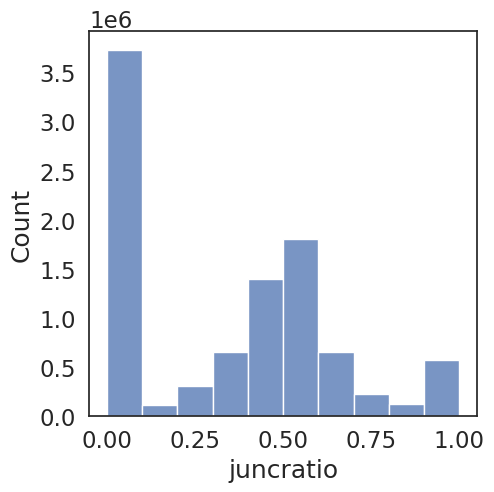

In [10]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [11]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_78692220_78694195,114,12,1,78692220,78694195,0
1,1_78694346_78696080,114,13,1,78694346,78696080,1
2,1_74236899_74246079,344,20,1,74236899,74246079,2
3,1_74246114_74248131,344,21,1,74246114,74248131,3
4,1_74255014_74255957,347,22,1,74255014,74255957,4


In [12]:
cell_ids_conversion.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [13]:
print(len(junc_info.junction_id.unique()))
print(len(junc_info.Cluster.unique()))

19164
6388


In [14]:
cell_ids_conversion["cell_type"] = np.random.choice([1,2], size=len(cell_ids_conversion))
cell_ids_conversion

,cell_id_index,cell_id,cell_type
6,0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,1
17029,1,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1
39773,2,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2
58704,3,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,2
93362,4,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,1
...,...,...,...
38830678,2400,P9-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,1
38842981,2401,P9-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2
38856962,2402,P9-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,1
38880113,2403,P9-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,1


In [15]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 2
The number of cells is: 2405
The number of junctions is: 19164


100%|██████████| 6388/6388 [00:16<00:00, 376.56it/s]


The columns to keep are: Index([0, 1], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [16]:
# Check outcome of cluster_labels
print(cluster_labels)

           0         1  new_junction_id_index sample_label  Cluster
0   0.422694  0.422694                      0     negative      114
2   0.422694  0.422694                      1     negative      114
0   0.081455  0.081455                      2     negative      344
2   0.081455  0.081455                      3     negative      344
0   0.253225  0.253225                      4     negative      347
..       ...       ...                    ...          ...      ...
1   0.824693  0.102305                  19159     positive      219
1   0.634932  0.634932                  19160     negative   116052
1   0.000150  0.000150                  19161     negative    23116
1   0.920100  0.920100                  19162     negative   118988
1   0.543716  0.679523                  19163     positive    75653

[19164 rows x 5 columns]


In [17]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

In [18]:
# get variance in simulated psi values across all simulated cell types 
K = len(np.unique(cell_types))
print(K)

2


In [19]:
cell_type_psi_df

,0,1,new_junction_id_index,sample_label,Cluster
0,0.422694,0.422694,0,negative,114
2,0.422694,0.422694,1,negative,114
0,0.081455,0.081455,2,negative,344
2,0.081455,0.081455,3,negative,344
0,0.253225,0.253225,4,negative,347
...,...,...,...,...,...
1,0.824693,0.102305,19159,positive,219
1,0.634932,0.634932,19160,negative,116052
1,0.000150,0.000150,19161,negative,23116
1,0.920100,0.920100,19162,negative,118988


<Axes: >

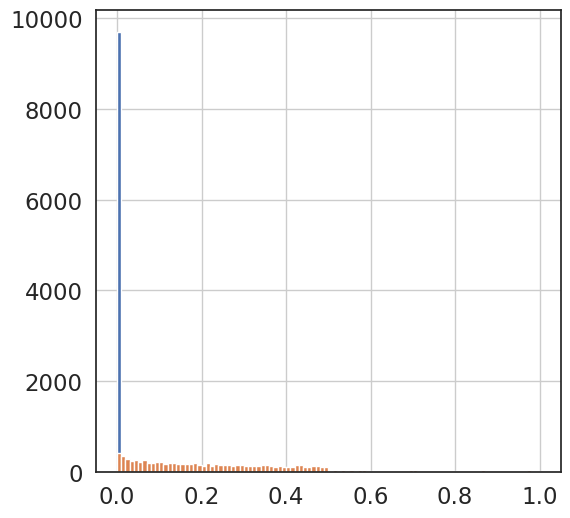

In [20]:
cell_type_psi_df["difference"] = cell_type_psi_df[0] - cell_type_psi_df[1]
cell_type_psi_df["difference"] = np.abs(cell_type_psi_df["difference"])

# make histogram which just rows where sample_label is negative and one where it's positive
cell_type_psi_df[cell_type_psi_df["sample_label"] == "negative"]["difference"].hist(bins=100, range=(0,1))
cell_type_psi_df[cell_type_psi_df["sample_label"] == "positive"]["difference"].hist(bins=100, range=(0,1))

<Axes: >

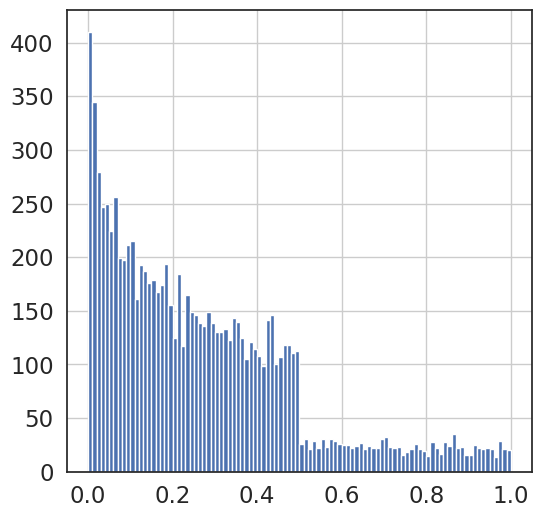

In [21]:
# make a histogram of differences in psi values just for junctions from sample_label == positive
cell_type_psi_df[cell_type_psi_df["sample_label"] == "positive"]["difference"].hist(bins=100, range=(0,1))

In [22]:
# Figure out which clusters with positive labels have junctions in them with diff < 0.1 
relabel_clusts = cell_type_psi_df[(cell_type_psi_df["sample_label"] == "positive") & (cell_type_psi_df["difference"] < 0.1)].Cluster.unique()

In [23]:
# make new column named "true_label" which is the same as sample_label but for clusters that in relabel_clusts rename them to negative 
cell_type_psi_df["true_label"] = cell_type_psi_df["sample_label"]
cell_type_psi_df.loc[cell_type_psi_df["Cluster"].isin(relabel_clusts), "true_label"] = "negative"
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
print(cell_type_psi_df.true_label.value_counts(), cell_type_psi_df.sample_label.value_counts())

true_label
negative    12738
positive     6426
Name: count, dtype: int64 sample_label
negative    9696
positive    9468
Name: count, dtype: int64


In [24]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,11.0,0
1,0,1,6.0,0
2,0,2,2.0,0
3,0,3,1.0,0
4,0,4,13.0,0


In [25]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,new_junction_id_index,new_junc_count,new_cell_type
0,1225,12,6.0,8,2.0,0.750000,I2-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,1
1,333,12,46.0,79,33.0,0.582278,C2-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,25.0,0
2,1112,12,6.0,6,0.0,1.000000,H5-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
3,1670,12,41.0,73,32.0,0.561644,L17-B002432-3_38_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,30.0,0
4,1976,12,3.0,5,2.0,0.600000,N16-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,2.0,1


In [26]:
# remove gene_id_x column and rename gene_id_y to just gene_id
final_data.drop(columns = ["gene_id_x"], inplace = True)
final_data.rename(columns = {"gene_id_y": "gene_id"}, inplace = True)

In [27]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,junction_id_index,junc_count,new_cell_type
0,1225,8,2.0,0.750000,I2-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,1.0,1
1,333,79,33.0,0.582278,C2-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,25.0,0
2,1112,6,0.0,1.000000,H5-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,0.0,0
3,1670,73,32.0,0.561644,L17-B002432-3_38_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,0,30.0,0
4,1976,5,2.0,0.600000,N16-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,2.0,1


In [28]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

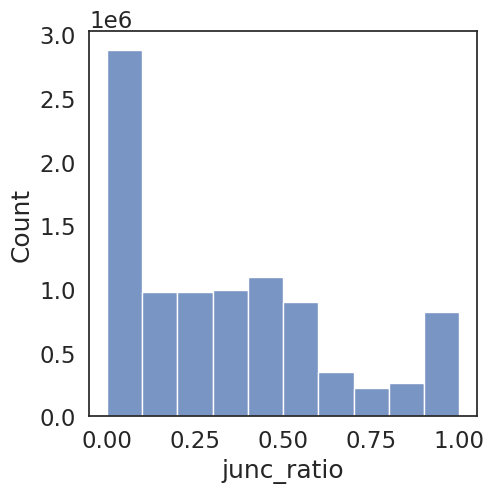

In [29]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

### Prep data for model 

In [30]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [31]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [32]:
clust_labels_only = cluster_labels[["Cluster", "true_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,true_label
0,1225,114,Mammary_Gland_basal_cell,0,0.142857,1.0,7.0,negative
1,333,114,Mammary_Gland_basal_cell,0,0.337838,25.0,74.0,negative
2,1112,114,Mammary_Gland_basal_cell,0,0.000000,0.0,4.0,negative
3,1670,114,Mammary_Gland_stromal_cell,0,0.410959,30.0,73.0,negative
4,1976,114,Mammary_Gland_basal_cell,0,0.666667,2.0,3.0,negative


In [33]:
# update cell_type column in simple data to what it is in cell_ids_conversion using cell_id_index and make sure it's a category
simple_data.drop(columns = ["cell_type"], inplace = True)
simple_data = simple_data.merge(cell_ids_conversion, on = ["cell_id_index"])
simple_data["cell_type"] = simple_data["cell_type"].astype('category')
simple_data.head()

,cell_id_index,Cluster,junction_id_index,junc_ratio,junc_count,cluster_count,true_label,cell_id,cell_type
0,1225,114,0,0.142857,1.0,7.0,negative,I2-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,2
1,333,114,0,0.337838,25.0,74.0,negative,C2-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,1
2,1112,114,0,0.000000,0.0,4.0,negative,H5-B000168-3_57_F-1-1_Mammary_Gland_basal_cell,1
3,1670,114,0,0.410959,30.0,73.0,negative,L17-B002432-3_38_F-1-1_Mammary_Gland_stromal_cell,1
4,1976,114,0,0.666667,2.0,3.0,negative,N16-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,2


In [34]:
def quick_clust_plot(clust, simple_data, num_cols=3, plot_states_arb=True):
    
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    sample_label = simple_data_junc.true_label.unique()[0]
    
    # if plot_states_arb = True then instead of real cell types make dummy variable and use that for cell type
    if plot_states_arb:
        # get unique values in cell type and mapping to a number 
        cell_types = simple_data_junc.cell_type.unique()
        cell_type_map = dict(zip(cell_types, range(len(cell_types))))
        simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
        #make sure new values in cell_Type are string
        simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
    
    plt.figuresize=(6, 6)

    # choose three distrinct colours to use for junction_id_index hue 
    colors = sns.color_palette("husl", num_cols)

    # use colors in violinplot
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index", palette=colors)

    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title(sample_label + " label for cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # put legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)
    plt.show()

/scratch/ipykernel_13650/2991430445.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
/scratch/ipykernel_13650/2991430445.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before

62639
cell_type
2    132
1    117
Name: count, dtype: int64


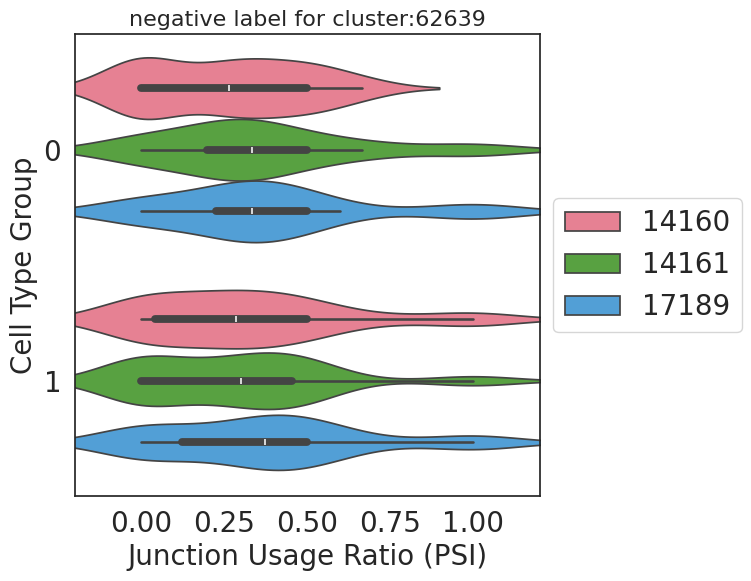

In [35]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
quick_clust_plot(clust, simple_data)

In [36]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [37]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [38]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [39]:
# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.cluster_count, indices))

### Evaluate model performance when masking some of the input data

In [40]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *
import cost_correlation_assign
from cost_correlation_assign import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

### Run full model

In [41]:
full_total_counts_tensor

tensor(indices=tensor([[ 1225,   333,  1112,  ...,  1762,    61,   242],
                       [    0,     0,     0,  ..., 19163, 19163, 19163]]),
       values=tensor([ 7., 74.,  4.,  ..., 14.,  1., 53.]),
       size=(2405, 19164), nnz=9594318, layout=torch.sparse_coo)

In [68]:
reload(factor_model)
best_K = 2
K = best_K
#input_conc = 50
# set input_conc to inf
input_conc = float('inf')
input_conc = None
all_results, variable_sizes = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=10, use_global_prior=False, K=K, lr=0.1, input_conc_prior=input_conc, loss_plot=False, num_epochs=5, save_to_file = False)

No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
Not using priors on a and b, running simpler non-hierarchical version!


2.3.0+cu121
12.1
Random seeds: [6989]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 6989
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
++++++ GUIDE CALLED ++++++
Guide parameters:
assign: tensor([[0.4559, 0.5441],
        [0.5497, 0.4503],
        [0.4700, 0.5300],
        ...,
        [0.4048, 0.5952],
        [0.4430, 0.5570],
        [0.4526, 0.5474]], grad_fn=<SoftmaxBackward0>)
psi shape: tensor([[0.5962, 0.4821, 0.4400,  ..., 0.5773, 0.5132, 0.5659],
        [0.4420, 0.5541, 0.5214,  ..., 0.4588, 0.5227, 0.5319]],
       grad_fn=<SigmoidBackward0>)
input_conc shape: 7.292304992675781
a shape: 2.451441764831543
b shape: 2.7266526222229004
pi shape: tensor([0.4290, 0.5710], grad_fn=<SoftmaxBackward0>)
conc shape: 2.6859498023986816
++++++ MODEL CALLED ++++++
a:  tensor(0.3545)
b:  tensor(1.2698)
psi:  tensor([[3.2545e-01, 2.2365e-02, 7.7

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/pyro/util.py:288: UserWarning: Found non-auxiliary vars in guide but not model, consider marking these infer={'is_auxiliary': True}:
{'a', 'b', 'pi', 'assign', 'y', 'dir_conc'}
  warnings.warn(
Elbo loss: 87190648.91102365


Sample from the guide (posterior)
++++++ GUIDE CALLED ++++++
Guide parameters:
assign: tensor([[0.6356, 0.3644],
        [0.6148, 0.3852],
        [0.5173, 0.4827],
        ...,
        [0.4775, 0.5225],
        [0.5733, 0.4267],
        [0.4657, 0.5343]], grad_fn=<SoftmaxBackward0>)
psi shape: tensor([[0.6054, 0.4084, 0.5212,  ..., 0.5078, 0.5223, 0.5487],
        [0.4638, 0.4428, 0.6000,  ..., 0.3497, 0.5391, 0.4633]],
       grad_fn=<SigmoidBackward0>)
input_conc shape: 7.237564563751221
a shape: 2.8674826622009277
b shape: 3.0349838733673096
pi shape: tensor([0.3642, 0.6358], grad_fn=<SoftmaxBackward0>)
conc shape: 2.5989131927490234
++++++ GUIDE CALLED ++++++
Guide parameters:
assign: tensor([[0.4537, 0.5463],
        [0.4489, 0.5511],
        [0.4670, 0.5330],
        ...,
        [0.4501, 0.5499],
        [0.5020, 0.4980],
        [0.5516, 0.4484]], grad_fn=<SoftmaxBackward0>)
psi shape: tensor([[0.6399, 0.4318, 0.5048,  ..., 0.4740, 0.5387, 0.4119],
        [0.5478, 0.4956, 0.5

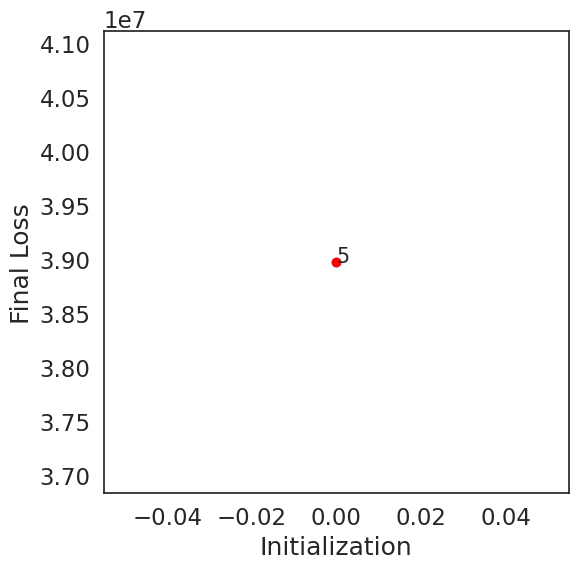

In [43]:
# figure out which index in all_results has the lowest final loss
losses = [result["losses"][-1] for result in all_results]
# get number of epochs for each initialization
num_epochs = [len(result["losses"]) for result in all_results]

# make a quick plot of the losses
plt.plot(losses)
plt.xlabel("Initialization")
plt.ylabel("Final Loss")
# make each loss value with a dot 
plt.scatter(range(len(losses)), losses)
# also mark the number of epochs
for i in range(len(losses)):
    plt.text(i, losses[i], str(num_epochs[i]), size="small")
# mark the lowest loss red
plt.scatter(np.argmin(losses), np.min(losses), color="red")

In [44]:
# Let's get assign matrix for each initialization
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in all_results]
len(assign_matrices)

1

In [45]:
# Usage
corrs, matchings = compare_assignments(assign_matrices)

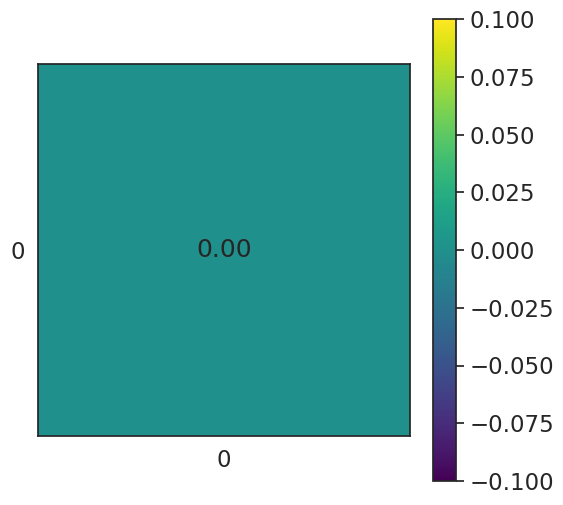

In [46]:
# plot the correlation matrix
plt.imshow(corrs, cmap="viridis")

# add colorbar
plt.colorbar()
# make the ticks show the initialization number
plt.xticks(range(len(corrs)), range(0, len(corrs)))
plt.yticks(range(len(corrs)), range(0, len(corrs)))
# print the correlation values
for i in range(len(corrs)):
    for j in range(len(corrs)):
        plt.text(i, j, f"{corrs[i, j]:.2f}", ha="center", va="center")

In [47]:
def average_pairwise_correlation(corrs):
    # Use tril_indices to access the lower triangle excluding the diagonal
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.mean(corrs[i, j])

def median_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.median(corrs[i, j])

def min_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.min(corrs[i, j])

# Calculate the average pairwise correlation
average_corr = average_pairwise_correlation(corrs)
print(f"Average Pairwise Correlation: {average_corr}")

consistency_index = average_corr / 1.0  # Since correlation's maximum is 1
print(f"Consistency Index: {consistency_index}")

median_corr = median_pairwise_correlation(corrs)
print(f"Median Pairwise Correlation: {median_corr}")

min_corr = min_pairwise_correlation(corrs)
print(f"Minimum Pairwise Correlation: {min_corr}")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Average Pairwise Correlation: nan
Consistency Index: nan
Median Pairwise Correlation: nan


ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
# get the index of initialization with the lowest loss
best_init = np.argmin(losses)
print("The best initialization was: ", best_init)

# extract latent variables for just first seed used 
latent_vars = all_results[best_init]['summary_stats'] 

pi = latent_vars["pi"]["mean"] # overall contribution of each factor to cell population, one value per k
dir_conc = latent_vars["dir_conc"]["mean"] # one scaling value 
assign_post = latent_vars["assign"]["mean"]
psis = latent_vars["psi"]["mean"] # psi is the probability of a junction being used in a cluster
a = latent_vars["a"]["mean"] 
b = latent_vars["b"]["mean"] 
bb_conc = latent_vars["bb_conc"]["mean"] # concentration parameter for beta-binomial distribution

print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))
print("The inferred bb_conc parameter is: " + str(bb_conc))

In [ ]:
latent_vars["assign"]

In [ ]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

In [ ]:
cell_types_id.new_cell_type.value_counts()

In [ ]:
assign_post

In [ ]:
assign_post_df = pd.DataFrame(assign_post)

In [ ]:
variable_sizes

In [ ]:
# print pyro params guide variables 
print("The pyro params guide variables are: ")
pyro.get_param_store().keys()

In [ ]:
# get length of params in each key of param store
for key in pyro.get_param_store().keys():
    print(key, len(pyro.get_param_store()[key]))

In [ ]:
Guide variable sizes: {'data': torch.Size([2405]), '_AutoGuideList.0_latent': torch.Size([79063]), 'a': torch.Size([19164]), 'b': torch.Size([19164]), 'psi': torch.Size([2, 19164]), 'pi': torch.Size([2]), 'dir_conc': torch.Size([]), 'assign': torch.Size([2405, 2]), '_AutoGuideList.1_latent': torch.Size([1]), 'bb_conc': torch.Size([])}
------------------------------------------------
Model variable sizes: {'bb_conc': torch.Size([]), 'a': torch.Size([19164]), 'b': torch.Size([19164]), 'psi': torch.Size([2, 19164]), 'pi': torch.Size([2]), 'dir_conc': torch.Size([]), 'data': torch.Size([2405]), 'assign': torch.Size([2405, 2])}
------------------------------------------------

In [ ]:
# using varaible sizes and dimensions indicated there calculate total number of expected values to have a mean and SD from normal posterior 
tot_params = 0 
start_idx = 0
params = {}

for name, size in variable_sizes.items():
    print(name)
    if len(size) == 1:
        tot_params += size[0]
        numel = int(size[0])  # Total number of elements in the tensor
        print("Number of parameters: ", size[0])
    else:
        tot_params += np.prod(size)
        numel = int(np.prod(size))  # Total number of elements in the tensor
        print("Number of parameters: ", np.prod(size))

    end_idx = start_idx + numel
    print(name, start_idx, end_idx)
    params[f"{name}_loc"] = pyro.param("AutoGuideList.0.loc")[start_idx:end_idx]
    params[f"{name}_scale"] = pyro.param("AutoGuideList.0.scale")[start_idx:end_idx]
    start_idx = end_idx

print(tot_params)

In [ ]:
params

In [ ]:
pyro.param("AutoGuideList.0.loc")

In [ ]:
# compile variable sizes for the model where [] indicates scalar so one value 
params = {}
start_idx = 0

for name, size in variable_sizes.items():
    # print(name, size)
    numel = size.numel()  # Total number of elements in the tensor
    end_idx = start_idx + numel
    print(name, start_idx, end_idx)
    params[f"{name}_loc"] = pyro.param("AutoGuideList.0.loc")[start_idx:end_idx]
    params[f"{name}_scale"] = pyro.param("AutoGuideList.0.scale")[start_idx:end_idx]
    start_idx = end_idx

In [ ]:
# get total length of all parameters
total_params = sum([size.numel() for size in variable_sizes.values()])
print(total_params)

In [ ]:
# Print the separated parameters for verification
for key, value in params.items():
    # convert tensor to cpu
    value = value.cpu()
    print(f"{key}: {value.data.numpy()}, length: {len(value)}")

In [ ]:
# extract the psi_loc and psi_scale values means and standard deviations and convert into K by J 
psi_loc = params["psi_loc"].reshape(K, -1)
psi_scale = params["psi_scale"].reshape(K, -1)

In [ ]:
# whi is assign_loc and assign_scale "[]" / empty above?
plot_bb=True

In [ ]:
J = psis.shape[1]
jj = np.random.randint(J)
jj = 163
from scipy.stats import beta

if plot_bb:

    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    success_probs = psis[:,jj]
    bbconc_param = bb_conc
    print(f"The bb conc param is {bbconc_param}")
    conc_params = [10, bbconc_param, 1000]
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    # Define a single legend for all curves
    legend_labels = []

    for i, conc_param in enumerate(conc_params):

        # Plot individual curves for each success probability
        for j, success_prob in enumerate(success_probs):
            # Calculate shape parameters for the Beta distribution
            bb_alpha = success_prob * conc_param
            bb_beta = (1 - success_prob) * conc_param

            # Calculate the probability density function (PDF) of the beta distribution
            pdf = beta.pdf(x, bb_alpha, bb_beta)

            # Plot the Beta distribution
            # axs[i].plot(x, pdf, label=f'Success Prob {j+1}: {success_prob:.2f}')
            # Plot the Beta distribution and store the label for the legend
            line, = axs[i].plot(x, pdf, label=f'Success Prob {jj+1}: {success_prob:.2f}')
            if i == 0:  # Add legend labels only once
                legend_labels.append(line.get_label())
            
        axs[i].set_title(f'Beta Distribution (Cell State: {conc_param})', fontsize=10)
        axs[i].set_xlabel('x')
        axs[i].set_ylabel('Probability Density')
        axs[i].grid(True)

    # Also plot the Beta distribution average junction behaviour using a_j and b_j values
    # in this case just a[1] and b[1] for the current junction 
    bb_alpha = a[jj]
    bb_beta = b[jj]
    bb_avg = bb_alpha / (bb_alpha+bb_beta)
    print(f"The average junction behaviour is: {bb_avg:.2f}")
    pdf = beta.pdf(x, bb_alpha, bb_beta)
    axs[3].plot(x, pdf, label=f'Average Junction Behaviour')
    axs[3].set_title('Beta Distribution (Average Junction Behaviour)', fontsize=10)
    axs[3].set_xlabel('x')
    axs[3].set_ylabel('Probability Density')
    axs[3].grid(True)
    
    # extract only unique values from legend lines 
    fig.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    # print the plot
    # print axs[2]

    plt.show()

### Evaluate latent factor space

In [ ]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [ ]:
cell_ids_conversion

In [ ]:
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=35, c=cell_colors
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

In [ ]:
assign_post

In [ ]:
# make simple scatter plot of assign_post matrix
plt.figure(figsize=(6, 6))
plt.scatter(assign_post[:,0], assign_post[:,1], c=cell_colors)
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")

In [ ]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=12)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [ ]:
# convert into a data frame
psi_df = pd.DataFrame(psis)

In [ ]:
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
# Get collors 
colors = sns.color_palette("tab20", num_unique_types)

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.cell_type.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

In [ ]:
# Now let's implement ALBF so can see which junctions are selected to be differentially spliced and then see if this corresponds to the true labels that were simulated
